# 03 · Nettoyage de la table CIQUAL 2020 (C3)

**Objectif :** produire un jeu d'aliments propre, prêt pour l'import PostgreSQL, à partir du fichier brut CIQUAL.

**Principe directeur :** une entrée *corrompue* (inutilisable) n'est pas une entrée *non scorable*.
Les règles de non-calcul du score (complétude < 50 %, apport < 1 g) relèvent du calcul à la volée,
pas du nettoyage. Un aliment sans score reste en base pour que l'application affiche « Score indisponible ».

**Source :** Anses. 2020. Table de composition nutritionnelle des aliments Ciqual. Licence Ouverte / Etalab 2.0.
Version 2020 conservée volontairement : le référentiel de score v1.0 est calibré dessus (Ciqual 2025 publiée en 11/2025, migration = recalibration v2.0).

--------------------------
## 0.1 Imports, chemins et constantes

In [1]:
from pathlib import Path
import re

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 80)

CIQUAL_VERSION = "2020"   # ne pas changer sans recalibrer le référentiel de score (v1.0 calibré sur 2020)
CIQUAL_XLS_URL = "https://www.data.gouv.fr/api/1/datasets/r/bcdb7fec-875c-42aa-ba6e-460adf97aad3"
RAW_FILE  = Path("data/raw") / f"ciqual_{CIQUAL_VERSION}.xls"
CLEAN_DIR = Path("data/clean")
CITATION  = "Anses. 2020. Table de composition nutritionnelle des aliments Ciqual."

In [2]:
# Téléchargement 
def download_ciqual(url: str, dest: Path, force: bool = False) -> Path:
    """Télécharge le fichier CIQUAL s'il n'est pas déjà en cache local. 
    (ne retélécharge pas si le fichier existe déjà (sauf force=True).)
    """
    dest.parent.mkdir(parents=True, exist_ok=True)
    if dest.exists() and not force:
        print(f"Déjà présent : {dest} ({dest.stat().st_size/1_000_000:.1f} Mo)")
        return dest
    print(f"Téléchargement CIQUAL depuis data.gouv.fr…")
    with requests.get(url, stream=True, timeout=60,
                      headers={"User-Agent": "Alimendo-datacollect/1.0"}) as r:
        r.raise_for_status()
        with open(dest, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)
    print(f"Enregistré : {dest} ({dest.stat().st_size/1_000_000:.1f} Mo)")
    return dest

## 0.2 Chargement BRUT : aucune conversion, tout reste du texte
Différence avec load_ciqual() du notebook 01 :   
on force dtype=str et on désactive la détection automatique des NaN.   
**Objectif :** voir les valeurs EXACTEMENT comme dans la source ('-', 'traces', '< 0,1', '12,5'…) avant de décider comment les convertir.


In [3]:
def load_ciqual_brut(path: Path) -> tuple[pd.DataFrame, str]:
    """Charge le fichier CIQUAL sans aucune interprétation des valeurs.

    Retourne (DataFrame 100 % texte, format détecté).
    Lève ValueError si le format n'est pas reconnu (plutôt que de deviner).
    """
    head = path.read_bytes()[:8]
    opts = dict(dtype=str, keep_default_na=False, na_values=[])  # cellule vide -> '' (pas NaN)
    if head.startswith(b"PK\x03\x04"):                 # zip -> xlsx
        return pd.read_excel(path, engine="openpyxl", **opts), "xlsx"
    if head.startswith(b"\xD0\xCF\x11\xE0"):            # OLE2 -> xls Excel 97-2003
        return pd.read_excel(path, engine="xlrd", **opts), "xls (OLE2)"
    if head.lstrip()[:1] == b"<":                       # export HTML déguisé en .xls
        # thousands=None : sinon '12,5' serait lu comme 125 (séparateur de milliers par défaut)
        df = pd.read_html(path, thousands=None, keep_default_na=False)[0]
        return df.astype(str), "html déguisé en .xls"
    raise ValueError(f"Format CIQUAL non reconnu (premiers octets : {head!r})")


path = download_ciqual(CIQUAL_XLS_URL, RAW_FILE)
brut, fmt = load_ciqual_brut(path)
assert len(brut) > 0, "Le fichier CIQUAL est vide"

print(f"Source : {CITATION}")
print(f"Format détecté : {fmt}")
print(f"Dimensions brutes : {brut.shape[0]} lignes × {brut.shape[1]} colonnes")
print("Types pandas :", brut.dtypes.astype(str).value_counts().to_dict())  # attendu : 100 % texte
display(brut.head(3))

Déjà présent : data/raw/ciqual_2020.xls (3.6 Mo)
Source : Anses. 2020. Table de composition nutritionnelle des aliments Ciqual.
Format détecté : xls (OLE2)
Dimensions brutes : 3186 lignes × 76 colonnes
Types pandas : {'str': 76}


,alim_grp_code,alim_ssgrp_code,alim_ssssgrp_code,alim_grp_nom_fr,alim_ssgrp_nom_fr,alim_ssssgrp_nom_fr,alim_code,alim_nom_fr,alim_nom_sci,"Energie, Règlement UE N° 1169/2011 (kJ/100 g)","Energie, Règlement UE N° 1169/2011 (kcal/100 g)","Energie, N x facteur Jones, avec fibres (kJ/100 g)","Energie, N x facteur Jones, avec fibres (kcal/100 g)",Eau (g/100 g),"Protéines, N x facteur de Jones (g/100 g)","Protéines, N x 6.25 (g/100 g)",Glucides (g/100 g),Lipides (g/100 g),Sucres (g/100 g),Fructose (g/100 g),Galactose (g/100 g),Glucose (g/100 g),Lactose (g/100 g),Maltose (g/100 g),Saccharose (g/100 g),...,Chlorure (mg/100 g),Cuivre (mg/100 g),Fer (mg/100 g),Iode (µg/100 g),Magnésium (mg/100 g),Manganèse (mg/100 g),Phosphore (mg/100 g),Potassium (mg/100 g),Sélénium (µg/100 g),Sodium (mg/100 g),Zinc (mg/100 g),Rétinol (µg/100 g),Beta-Carotène (µg/100 g),Vitamine D (µg/100 g),Vitamine E (mg/100 g),Vitamine K1 (µg/100 g),Vitamine K2 (µg/100 g),Vitamine C (mg/100 g),Vitamine B1 ou Thiamine (mg/100 g),Vitamine B2 ou Riboflavine (mg/100 g),Vitamine B3 ou PP ou Niacine (mg/100 g),Vitamine B5 ou Acide pantothénique (mg/100 g),Vitamine B6 (mg/100 g),Vitamine B9 ou Folates totaux (µg/100 g),Vitamine B12 (µg/100 g)
0,00,0000,000000,,,,24999,Dessert (aliment moyen),,,,,,"45,4","4,63","4,61","36,6","12,9","23,7","1,81",,"2,18","1,89","1,07","15,7",...,178,"0,15","1,45",11,"23,8","0,23",107,181,"7,04",153,"0,5","56,3","34,6","0,27","1,97",,,"1,37","0,084","0,15","0,61","0,4","0,056","30,8","0,21"
1,01,0101,000000,entrées et plats composés,salades composées et crudités,-,25601,"Salade de thon et légumes, appertisée",,-,-,-,-,"76,5","9,15","9,15","7,74","4,7","3,08","0,82",-,"0,78",-,"< 0,3","0,97",...,731,"0,1","1,1",2,"25,1","0,1","88,4",232,-,445,"0,6",< 2,-,"< 0,5","1,6",-,-,"2,75","< 0,04","0,053","4,45","< 0,16","0,29",31,"1,45"
2,01,0101,000000,entrées et plats composés,salades composées et crudités,-,25602,"Salade composée avec viande ou poisson, appertisée",,-,-,-,-,"76,7","8,06","8,06","6,4","5,3","1,9","0,7",-,"0,6","< 0,2","< 0,2","0,6",...,584,"0,07","0,7",< 20,20,"0,1",92,220,30,381,"0,38",< 21,781,"0,44","2,04","9,75",-,-,"0,032","0,022","4,13","0,2","0,12","11,1","1,23"


------------------------
## 1. Audit structurel : identifiants, doublons, groupes
### 1.1 Identifiants et libellés : vides, unicité, format

In [4]:
cols_ident = ["alim_code", "alim_nom_fr", "alim_grp_code", "alim_grp_nom_fr",
              "alim_ssgrp_nom_fr", "alim_ssssgrp_nom_fr"]

ident_txt = brut[cols_ident].fillna("").apply(lambda s: s.str.strip())

audit_ident = pd.DataFrame({
    "vides":              (ident_txt == "").sum(),
    "tiret_seul":         (ident_txt == "-").sum(),
    "valeurs_distinctes": ident_txt.nunique(),
})
print("Tableau 1.1 — Complétude et unicité des colonnes d'identification")
display(audit_ident)

# alim_code doit être un entier unique : c'est la seule clé naturelle de la source
code_non_numerique = ~ident_txt["alim_code"].str.fullmatch(r"\d+")
print(f"alim_code non numériques : {code_non_numerique.sum()}")
print(f"alim_code dupliqués      : {ident_txt['alim_code'].duplicated(keep=False).sum()} lignes")
print(f"alim_nom_fr dupliqués    : {ident_txt['alim_nom_fr'].duplicated(keep=False).sum()} lignes")

Tableau 1.1 — Complétude et unicité des colonnes d'identification


,vides,tiret_seul,valeurs_distinctes
alim_code,0,0,3185
alim_nom_fr,0,0,3185
alim_grp_code,0,0,12
alim_grp_nom_fr,45,0,12
alim_ssgrp_nom_fr,45,1,65
alim_ssssgrp_nom_fr,45,1259,79


alim_code non numériques : 0
alim_code dupliqués      : 2 lignes
alim_nom_fr dupliqués    : 2 lignes


### 1.2 Lignes à examiner : noms dupliqués et aliments sans groupe

In [5]:
noms_dupliques = brut.loc[ident_txt["alim_nom_fr"].duplicated(keep=False),
                          ["alim_code", "alim_nom_fr", "alim_grp_nom_fr", "alim_ssgrp_nom_fr"]]
print(f"Tableau 1.2a — Noms dupliqués ({len(noms_dupliques)} lignes)")
display(noms_dupliques.sort_values("alim_nom_fr"))

sans_groupe = brut.loc[ident_txt["alim_grp_nom_fr"].isin(["", "-"]),
                       ["alim_code", "alim_grp_code", "alim_nom_fr"]]
print(f"Tableau 1.2b — Aliments sans groupe ({len(sans_groupe)} lignes)")
display(sans_groupe)

print("Tableau 1.2c — Répartition par groupe (code + nom)")
display(brut.groupby(["alim_grp_code", "alim_grp_nom_fr"]).size()
            .rename("n_aliments").reset_index())

Tableau 1.2a — Noms dupliqués (2 lignes)


,alim_code,alim_nom_fr,alim_grp_nom_fr,alim_ssgrp_nom_fr
3120,9621,Son de blé,aides culinaires et ingrédients divers,aides culinaires et ingrédients pour végétariens
3121,9621,Son de blé,aides culinaires et ingrédients divers,ingrédients divers


Tableau 1.2b — Aliments sans groupe (45 lignes)


,alim_code,alim_grp_code,alim_nom_fr
0,24999,00,Dessert (aliment moyen)
1097,4090,03,Fécule de pomme de terre
1098,9311,03,Flocon d'avoine
1099,9410,03,Farine de blé tendre ou froment T110
1100,9415,03,Farine de blé tendre ou froment T150
1101,9435,03,Farine de blé tendre ou froment T65
1102,9436,03,Farine de blé tendre ou froment T55 (pour pains)
1103,9437,03,Farine de blé tendre ou froment avec levure incorporée
1104,9440,03,Farine de blé tendre ou froment T45 (pour pâtisserie)
1105,9445,03,Farine de blé tendre ou froment T80


Tableau 1.2c — Répartition par groupe (code + nom)


,alim_grp_code,alim_grp_nom_fr,n_aliments
0,00,,1
1,01,entrées et plats composés,337
2,02,"fruits, légumes, légumineuses et oléagineux",614
3,03,,44
4,03,produits céréaliers,145
5,04,"viandes, œufs, poissons et assimilés",788
6,05,produits laitiers et assimilés,301
7,06,eaux et autres boissons,295
8,07,produits sucrés,306
9,08,glaces et sorbets,29


### Lecture § 1.1–1.2
- 3 185 codes distincts : un seul doublon, `alim_code` 9621 « Son de blé », présent dans deux sous-groupes.
- 45 lignes sans nom de groupe :
  - 44 de code `03` (farines, amidons, pâtes) : nom vide alors que 145 autres lignes `03` portent « produits céréaliers » → **format non normalisé** dans la source, pas une entrée corrompue (le code est présent).
  - 1 de code `00` « Dessert (aliment moyen) » : agrégat sans groupe.
- `alim_ssssgrp_nom_fr` : 1 259 « - » = absence de sous-sous-groupe → NULL au § 3.
-----------------------
### 1.3 Doublon alim_code 9621 « Son de blé » : même fiche ou deux fiches différentes ?


In [6]:
doublon_code = brut[ident_txt["alim_code"].duplicated(keep=False)]
assert len(doublon_code) == 2

cols_qui_different = [c for c in brut.columns if doublon_code[c].nunique() > 1]
print(f"Colonnes qui diffèrent entre les 2 lignes : {len(cols_qui_different)} / {brut.shape[1]}")
print("Tableau 1.3 — Valeurs qui diffèrent (une ligne par colonne)")
display(doublon_code[cols_qui_different].T)

Colonnes qui diffèrent entre les 2 lignes : 68 / 76
Tableau 1.3 — Valeurs qui diffèrent (une ligne par colonne)


,3120,3121
alim_ssgrp_nom_fr,aides culinaires et ingrédients pour végétariens,ingrédients divers
"Energie, Règlement UE N° 1169/2011 (kJ/100 g)",1160,
"Energie, Règlement UE N° 1169/2011 (kcal/100 g)",,279
"Energie, N x facteur Jones, avec fibres (kJ/100 g)",,1160
"Energie, N x facteur Jones, avec fibres (kcal/100 g)",,279
...,...,...
Vitamine B3 ou PP ou Niacine (mg/100 g),,"21,6"
Vitamine B5 ou Acide pantothénique (mg/100 g),,"2,29"
Vitamine B6 (mg/100 g),,"1,34"
Vitamine B9 ou Folates totaux (µg/100 g),,110


### 1.4 Aliments sans nom de groupe : peut-on récupérer le nom depuis le code ?


In [7]:
sans_nom_grp = ident_txt["alim_grp_nom_fr"] == ""
cols_codes = ["alim_grp_code", "alim_ssgrp_code", "alim_ssssgrp_code",
              "alim_ssgrp_nom_fr", "alim_ssssgrp_nom_fr"]

print("Tableau 1.4a — Codes de (sous-)groupe des 45 aliments sans nom de groupe")
display(brut.loc[sans_nom_grp, cols_codes].value_counts().rename("n").reset_index())

# Condition pour récupérer le nom depuis le code : chaque code groupe ne correspond qu'à UN nom
lignes_nommees = brut.loc[~sans_nom_grp]
noms_par_code = lignes_nommees.groupby("alim_grp_code")["alim_grp_nom_fr"].nunique()
print("Codes groupe associés à plus d'un nom :", noms_par_code[noms_par_code > 1].to_dict() or "aucun")

print("Tableau 1.4b — Sous-groupes nommés existants dans le groupe 03")
display(lignes_nommees[lignes_nommees["alim_grp_code"].str.strip() == "03"]
        .groupby(["alim_ssgrp_code", "alim_ssgrp_nom_fr"]).size()
        .rename("n").reset_index())

Tableau 1.4a — Codes de (sous-)groupe des 45 aliments sans nom de groupe


,alim_grp_code,alim_ssgrp_code,alim_ssssgrp_code,alim_ssgrp_nom_fr,alim_ssssgrp_nom_fr,n
0,03,0305,030501,,,22
1,03,0305,030502,,,22
2,00,0000,000000,,,1


Codes groupe associés à plus d'un nom : aucun
Tableau 1.4b — Sous-groupes nommés existants dans le groupe 03


,alim_ssgrp_code,alim_ssgrp_nom_fr,n
0,0301,"pâtes, riz et céréales",71
1,0302,pains et assimilés,56
2,0303,biscuits apéritifs,18


### 1.5 La ligne dont le sous-groupe vaut « - »

In [8]:
print("Tableau 1.5 — Aliment avec sous-groupe « - »")
display(brut.loc[ident_txt["alim_ssgrp_nom_fr"] == "-",
                 ["alim_code", "alim_nom_fr", "alim_grp_code", "alim_grp_nom_fr",
                  "alim_ssgrp_code", "alim_ssgrp_nom_fr"]])

Tableau 1.5 — Aliment avec sous-groupe « - »


,alim_code,alim_nom_fr,alim_grp_code,alim_grp_nom_fr,alim_ssgrp_code,alim_ssgrp_nom_fr
2831,39500,"Glace à l'eau ou sorbet ou crème glacée, tout parfum (aliment moyen)",08,glaces et sorbets,0000,-


### 1.6 Doublon 9621 : les deux lignes se contredisent-elles ou se complètent-elles ?

In [9]:
cols_nutri = [c for c in brut.columns if not c.startswith("alim_")]
print(f"Colonnes nutritionnelles : {len(cols_nutri)}")

VIDES = {"", "-"}
i1, i2 = doublon_code.index
v1 = doublon_code.loc[i1, cols_nutri].fillna("").str.strip()
v2 = doublon_code.loc[i2, cols_nutri].fillna("").str.strip()

def compare(a: str, b: str) -> str:
    """Compare deux valeurs brutes d'une même colonne."""
    a_ok, b_ok = a not in VIDES, b not in VIDES
    if a_ok and b_ok:
        return "identiques" if a == b else "CONFLIT"
    if a_ok:
        return f"seulement ligne {i1}"
    if b_ok:
        return f"seulement ligne {i2}"
    return "vide des deux côtés"

comparaison_9621 = pd.DataFrame({f"ligne_{i1}": v1, f"ligne_{i2}": v2})
comparaison_9621["statut"] = [compare(a, b) for a, b in zip(v1, v2)]

print("Tableau 1.6a — Bilan colonne par colonne")
display(comparaison_9621["statut"].value_counts().rename("n_colonnes").to_frame())
print("Tableau 1.6b — Colonnes en conflit (valeurs renseignées des deux côtés mais différentes)")
display(comparaison_9621[comparaison_9621["statut"] == "CONFLIT"])

Colonnes nutritionnelles : 67
Tableau 1.6a — Bilan colonne par colonne


,n_colonnes
statut,
seulement ligne 3121,63
vide des deux côtés,3
seulement ligne 3120,1


Tableau 1.6b — Colonnes en conflit (valeurs renseignées des deux côtés mais différentes)


,ligne_3120,ligne_3121,statut


## 2. Inventaire des formats non normalisés

----------------------
### 2.1 Classer chaque cellule nutritionnelle selon son format brut
Mesure sur TOUT le jeu (toutes les colonnes, pas seulement les 23 du score) :
c'est l'« identification des entrées au format non normalisé » demandée en C3.

In [10]:

FORMATS = ["nombre (point)", "nombre (virgule)", "vide", "tiret",
           "traces", "inférieur à (< X)", "autre texte"]

def classer_format(valeur) -> str:
    """Retourne le format d'une valeur brute CIQUAL (aucune conversion)."""
    v = "" if pd.isna(valeur) else str(valeur).replace("\xa0", " ").strip()
    if v == "":                                         return "vide"
    if v == "-":                                        return "tiret"
    if v.lower() == "traces":                           return "traces"
    if v.startswith("<"):                               return "inférieur à (< X)"
    if re.fullmatch(r"-?\d+(\.\d+)?([eE]-?\d+)?", v):   return "nombre (point)"   # cellule Excel numérique (dont 1e-05)
    if re.fullmatch(r"-?\d+,\d+", v):                   return "nombre (virgule)" # texte à la française
    return "autre texte"

# Garde-fou : la fonction sur des cas limites, avant de l'appliquer à 200 000 cellules
cas_limites = ["", " - ", "Traces", "< 0,1", "<0.5", "12", "12.5", "12,5", "-3",
               "1e-05", "\xa012,5", "1 200", "#REF!", None]
display(pd.DataFrame({"brut": [repr(c) for c in cas_limites],
                      "format": [classer_format(c) for c in cas_limites]}))

formats_cellules = brut[cols_nutri].apply(lambda col: col.map(classer_format))
inventaire_formats = (formats_cellules.apply(lambda col: col.value_counts()).T
                      .reindex(columns=FORMATS).fillna(0).astype(int))
inventaire_formats.index.name = "colonne CIQUAL"
assert inventaire_formats.sum(axis=1).eq(len(brut)).all(), "Chaque colonne doit compter toutes les lignes"

total_formats = inventaire_formats.sum().rename("n_cellules").to_frame()
total_formats["%"] = (100 * total_formats["n_cellules"] / total_formats["n_cellules"].sum()).round(2)
print(f"Tableau 2.1a — Formats sur l'ensemble des {len(cols_nutri)} colonnes × {len(brut)} aliments")
display(total_formats)

espaces_parasites = brut[cols_nutri].apply(
    lambda col: (col.fillna("") != col.fillna("").str.strip()) | col.fillna("").str.contains("\xa0")
).sum().sum()
print(f"Cellules avec espaces parasites (début/fin ou insécables) : {espaces_parasites}")

print("Tableau 2.1b — Valeurs « autre texte » rencontrées")
autres_textes = brut[cols_nutri].where(formats_cellules.eq("autre texte")).stack()
display(autres_textes.value_counts().rename("n").to_frame() if len(autres_textes) else "aucune")

,brut,format
0,'',vide
1,' - ',tiret
2,'Traces',traces
3,"'< 0,1'",inférieur à (< X)
4,'<0.5',inférieur à (< X)
5,'12',nombre (point)
6,'12.5',nombre (point)
7,"'12,5'",nombre (virgule)
8,'-3',nombre (point)
9,'1e-05',nombre (point)


Tableau 2.1a — Formats sur l'ensemble des 67 colonnes × 3186 aliments


,n_cellules,%
nombre (point),46619,21.84
nombre (virgule),83057,38.91
vide,1564,0.73
tiret,63688,29.84
traces,1904,0.89
inférieur à (< X),16630,7.79
autre texte,0,0.00


Cellules avec espaces parasites (début/fin ou insécables) : 0
Tableau 2.1b — Valeurs « autre texte » rencontrées


,n


### 2.2 Visualisation : part des valeurs non numériques par colonne
Une barre par colonne CIQUAL ; seules les valeurs NON numériques sont colorées,
le reste de la barre (jusqu'à 100 %) correspond aux valeurs numériques.

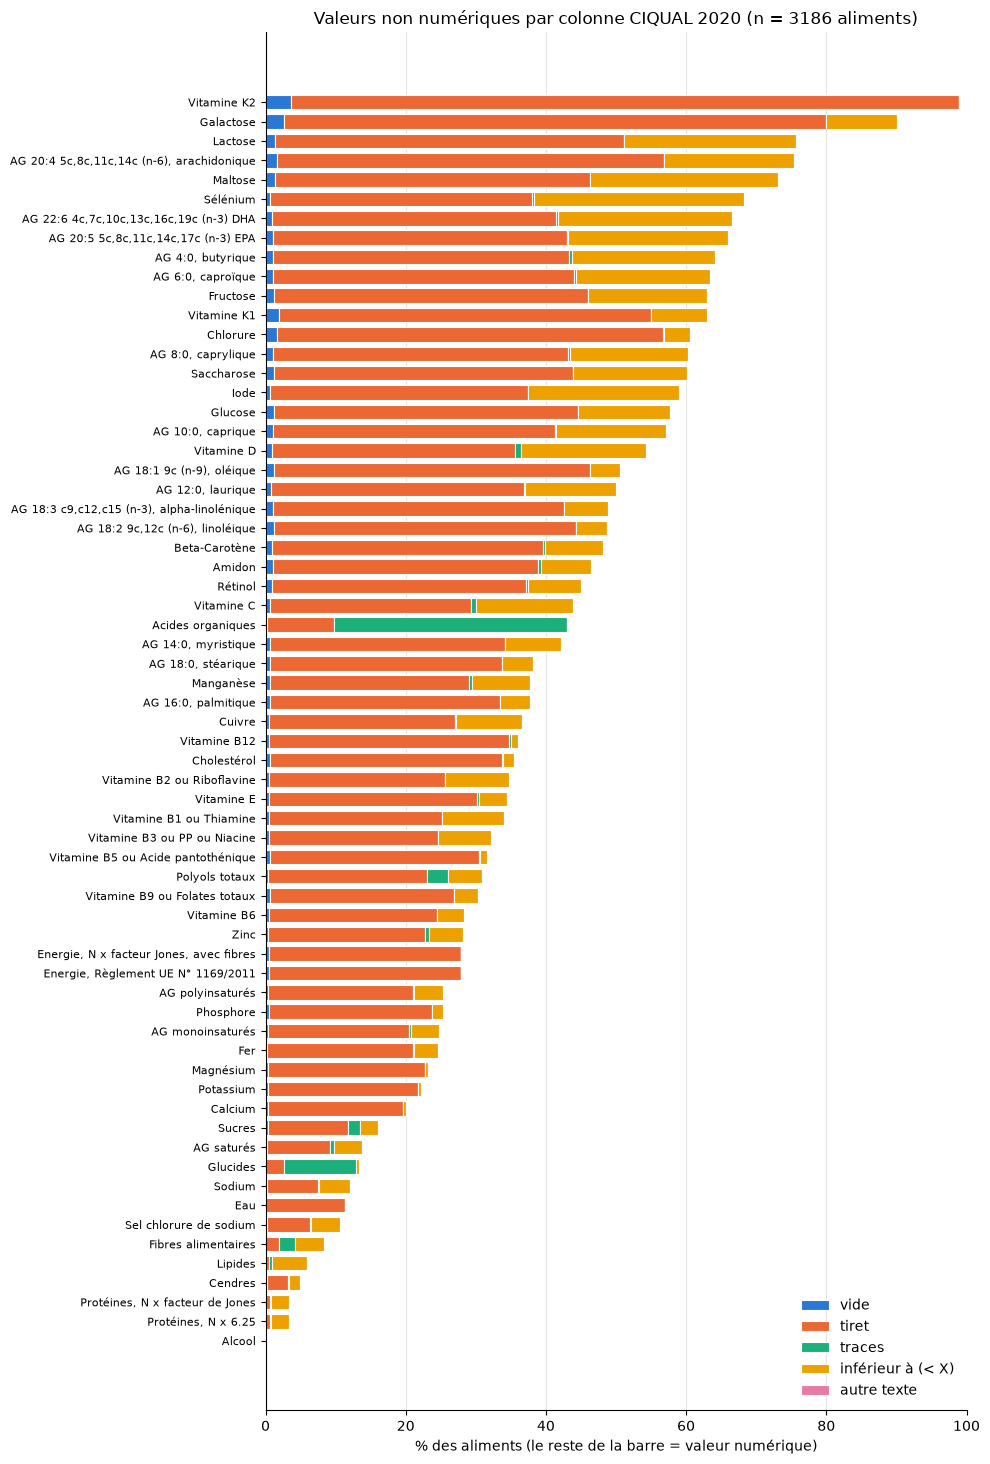

In [11]:

SEGMENTS = {"vide": "#2a78d6", "tiret": "#eb6834", "traces": "#1baf7a",
            "inférieur à (< X)": "#eda100", "autre texte": "#e87ba4"}

part_formats = 100 * inventaire_formats.div(inventaire_formats.sum(axis=1), axis=0)
part_formats = part_formats.loc[part_formats[list(SEGMENTS)].sum(axis=1).sort_values().index]
etiquettes = [re.sub(r"\s*\([^()]*/100 ?g\)\s*$", "", c)[:45] for c in part_formats.index]  # retire l'unité pour la lisibilité

fig, ax = plt.subplots(figsize=(10, max(4, 0.22 * len(part_formats))))
gauche = np.zeros(len(part_formats))
for fmt, couleur in SEGMENTS.items():
    ax.barh(etiquettes, part_formats[fmt], left=gauche, color=couleur, label=fmt,
            height=0.75, edgecolor="white", linewidth=0.8)
    gauche += part_formats[fmt].values
ax.set_xlim(0, 100)
ax.set_xlabel("% des aliments (le reste de la barre = valeur numérique)")
ax.set_title(f"Valeurs non numériques par colonne CIQUAL {CIQUAL_VERSION} (n = {len(brut)} aliments)")
ax.legend(loc="lower right", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="#e5e4e0", linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

### Lecture § 1.6 et 2.1–2.2
- **Doublon 9621 « Son de blé »** : 0 conflit. La ligne 3121 porte 63 valeurs, la ligne 3120 une seule absente de l'autre.
  -> Décision : **fusion** en une ligne (valeurs de 3121, complétées par 3120). Aucune perte, aucune valeur inventée.
- **Formats** (67 colonnes × 3 186 aliments) : nombres à point 21,8 % et à virgule 38,9 % mélangés dans les mêmes colonnes ;
  tiret 29,8 % ; « < X » 7,8 % ; traces 0,9 % ; cellule vide 0,7 % ; **0 texte inattendu, 0 espace parasite**.
- La cellule vide n'est pas documentée par l'ANSES (seul « - » l'est) → répartition à mesurer avant de décider.

### 2.3 Cellules vides : réparties sur tout le jeu ou concentrées sur quelques aliments ?

In [12]:
vides_par_aliment = formats_cellules.eq("vide").sum(axis=1)
print("Tableau 2.3a — Nombre de cellules vides par aliment")
display(vides_par_aliment.value_counts().sort_index().rename("n_aliments").to_frame())

aliments_avec_vides = (brut.loc[vides_par_aliment > 0, ["alim_code", "alim_nom_fr", "alim_grp_code"]]
                       .assign(n_vides=vides_par_aliment[vides_par_aliment > 0]))
print(f"Tableau 2.3b — Aliments ayant au moins une cellule vide ({len(aliments_avec_vides)}), les 40 plus vides")
display(aliments_avec_vides.sort_values("n_vides", ascending=False).head(40))

# Cas extrême : aucune valeur exploitable sur les 67 colonnes
sans_aucune_valeur = formats_cellules.isin(["vide", "tiret"]).all(axis=1)
print(f"Aliments sans AUCUNE valeur nutritionnelle (67 colonnes vides ou « - ») : {sans_aucune_valeur.sum()}")

Tableau 2.3a — Nombre de cellules vides par aliment


,n_aliments
0,3069
1,15
2,8
3,5
4,6
5,4
6,11
7,6
8,3
9,10


Tableau 2.3b — Aliments ayant au moins une cellule vide (117), les 40 plus vides


,alim_code,alim_nom_fr,alim_grp_code,n_vides
3120,9621,Son de blé,10,66
2230,18008,"Eau de source, embouteillée (aliment moyen)",06,53
2428,19120,"Boisson lactée aromatisée (arôme inconnu), sucrée, au lait partiellement écr...",06,51
307,25543,Sandwich baguette (aliment moyen),01,47
298,25522,Sandwich (aliment moyen),01,46
980,25579,"Gnocchi, cuit (aliment moyen)",03,44
2488,5003,Cidre (aliment moyen),06,42
2352,2053,"Jus de tomate, pur jus (aliment moyen)",06,40
1674,26999,"Anguille, cuite (aliment moyen)",04,37
1222,21523,"Agneau, viande, cuite (aliment moyen)",04,36


Aliments sans AUCUNE valeur nutritionnelle (67 colonnes vides ou « - ») : 0


### 2.4 « < X » et « traces » : une seule graphie, convertible sans ambiguïté ?


In [13]:
inferieurs = (brut[cols_nutri].where(formats_cellules.eq("inférieur à (< X)"))
              .stack().dropna().str.strip())
MOTIF_INFERIEUR = r"<\s*\d+([.,]\d+)?"          # « < » suivi d'un nombre, virgule ou point
bien_formes = inferieurs.str.fullmatch(MOTIF_INFERIEUR)
print(f"« < X » bien formés : {bien_formes.sum()} / {len(inferieurs)}")
print("Tableau 2.4a — « < X » mal formés (s'il y en a)")
display(inferieurs[~bien_formes].value_counts().rename("n").to_frame())

traces = (brut[cols_nutri].where(formats_cellules.eq("traces"))
          .stack().dropna().str.strip())
print("Tableau 2.4b — Graphies de « traces »")
display(traces.value_counts().rename("n").to_frame())

« < X » bien formés : 16630 / 16630
Tableau 2.4a — « < X » mal formés (s'il y en a)


,n


Tableau 2.4b — Graphies de « traces »


,n
traces,1904


### Lecture § 2.3–2.4
- 117 aliments ont ≥ 1 cellule vide (1 à 66), **0 aliment sans aucune valeur** → les cellules vides ne signalent pas d'entrée corrompue.
  L'aliment le plus vide (66) est la ligne 3120 du doublon 9621, déjà traitée par fusion.
- 16 630 / 16 630 « < X » bien formés ; « traces » : une seule graphie (1 904).
- Décision : cellule vide **et** « - » → NULL (non mesuré, jamais 0), conformément à la doc ANSES et au référentiel v1.0.

### 2.5 (documentation) Les cellules vides concernent-elles surtout les « aliments moyens » ?


In [14]:
est_moyen = brut["alim_nom_fr"].str.contains("aliment moyen", case=False, regex=False)
print("Tableau 2.5 — Aliments avec ≥ 1 cellule vide × aliment moyen")
display(pd.crosstab(est_moyen.rename("aliment_moyen"), (vides_par_aliment > 0).rename("a_des_vides"),
                    margins=True))

Tableau 2.5 — Aliments avec ≥ 1 cellule vide × aliment moyen


a_des_vides,False,True,All
aliment_moyen,,,
False,3068,2,3070
True,1,115,116
All,3069,117,3186


---------------------------------------------------
## 3. Conversion et homogénéisation
### 3.1 Conversion des valeurs brutes en nombres (référentiel v1.0, §4 étape 1)


In [15]:
# On réutilise classer_format() : la règle de conversion découle directement de l'inventaire du § 2.
def convertir_valeur(valeur) -> float:
    """Convertit une valeur brute CIQUAL en float.

    vide / '-'          -> NaN  (non mesuré : JAMAIS 0, doc ANSES)
    'traces' / '< X'    -> 0.0  (convention POC du référentiel v1.0 = « lower bound » EFSA)
    '12,5' / '12.5'     -> 12.5
    autre texte         -> NaN  (référentiel : erreur de source ; 0 cas mesuré au § 2)
    """
    fmt = classer_format(valeur)
    if fmt in ("vide", "tiret", "autre texte"):
        return np.nan
    if fmt in ("traces", "inférieur à (< X)"):
        return 0.0
    return float(str(valeur).replace("\xa0", "").strip().replace(",", "."))

# Garde-fou : cas limites avec résultat attendu
attendus = {"": np.nan, "-": np.nan, "traces": 0.0, "< 0,1": 0.0, "<0.5": 0.0,
            "12,5": 12.5, "12.5": 12.5, "0": 0.0, "1e-05": 1e-05, "#REF!": np.nan, None: np.nan}
for brute, attendu in attendus.items():
    obtenu = convertir_valeur(brute)
    assert (np.isnan(obtenu) and np.isnan(attendu)) or obtenu == attendu, f"{brute!r} -> {obtenu}, attendu {attendu}"
print("Cas limites : OK")

valeurs = brut[cols_nutri].apply(lambda col: col.map(convertir_valeur)).astype(float)

# Contrôle de cohérence : chaque valeur renseignée doit venir d'un format « nombre / traces / < X »
renseignees_attendues = formats_cellules.isin(
    ["nombre (point)", "nombre (virgule)", "traces", "inférieur à (< X)"]).sum()
assert (valeurs.notna().sum() == renseignees_attendues).all(), "Conversion incohérente avec l'inventaire"
print(f"Valeurs numériques obtenues : {int(valeurs.notna().sum().sum())} "
      f"| non mesurées (NULL) : {int(valeurs.isna().sum().sum())}")
print(f"Dont mises à 0 par convention (traces + < X) : {int(formats_cellules.isin(['traces', 'inférieur à (< X)']).sum().sum())}")

Cas limites : OK
Valeurs numériques obtenues : 148210 | non mesurées (NULL) : 65252
Dont mises à 0 par convention (traces + < X) : 18534


### Lecture § 2.5–3.1
- La cellule vide est la signature des **aliments moyens** : 115/116 en ont, contre 2/3 070 pour les autres aliments
  (dont la ligne 3120 du doublon). *Hypothèse d'interprétation* : constituant non calculable pour un agrégat. Traitement identique au « - » : NULL.
- Conversion vérifiée par recoupement avec l'inventaire du § 2 :
  148 210 valeurs + 65 252 NULL = 213 462 cellules (67 × 3 186) ; NULL = 63 688 tirets + 1 564 vides ;
  18 534 zéros de convention = 16 630 « < X » + 1 904 traces.

### 3.2 Dictionnaire de données : nom logique (= colonne BDD) -> colonne CIQUAL + contrôle des unités
Mots-clés repris du notebook 01 (params_directs), mais avec un garde-fou en plus :    
chaque mot-clé doit désigner UNE SEULE colonne (le notebook 01 prenait la première trouvée).
Unités attendues = table du score-referentiel.md §3. Si la source change d'unité, le script s'arrête

In [16]:
PARAMETRES = {
    "energie":           (["règlement ue", "kcal"], "kcal"),   # affichée, hors score
    "glucides":          (["glucides (g"], "g"),
    "proteines":         (["protéines, n x 6.25"], "g"),
    "lipides":           (["lipides (g"], "g"),
    "graisses_saturees": (["ag saturés"], "g"),
    "fibres":            (["fibres alimentaires"], "g"),
    "cholesterol":       (["cholestérol"], "mg"),
    "fer":               (["fer (mg"], "mg"),
    "magnesium":         (["magnésium"], "mg"),
    "selenium":          (["sélénium"], "µg"),
    "zinc":              (["zinc"], "mg"),
    "vitamine_a":        (["rétinol"], "µg"),
    "beta_carotene":     (["carotène"], "µg"),
    "vitamine_d":        (["vitamine d"], "µg"),
    "vitamine_e":        (["vitamine e"], "mg"),
    "vitamine_c":        (["vitamine c"], "mg"),
    "thiamine":          (["thiamine"], "mg"),
    "riboflavine":       (["riboflavine"], "mg"),
    "niacine":           (["niacine"], "mg"),
    "vitamine_b6":       (["vitamine b6"], "mg"),
    "folates":           (["folates"], "µg"),
    "vitamine_b12":      (["vitamine b12"], "µg"),
}
# Oméga : sommes d'acides gras (référentiel §3.3), toutes en g
COMPOSANTES_OMEGA = {"omega3": ["alpha-linolénique", "epa", "dha"],
                     "omega6": ["linoléique", "arachidonique"]}

def trouve_colonne_unique(colonnes, mots: list[str]) -> str:
    """Retourne LA colonne contenant tous les mots-clés ; erreur si 0 ou plusieurs."""
    candidates = [c for c in colonnes if all(m.lower() in c.lower() for m in mots)]
    if len(candidates) != 1:
        raise KeyError(f"{mots} -> {len(candidates)} colonne(s) : {candidates}")
    return candidates[0]

def unite_colonne(nom_colonne: str) -> str:
    """Extrait l'unité de l'en-tête CIQUAL, ex. 'Fer (mg/100 g)' -> 'mg'."""
    m = re.search(r"\(([^()/]+)/100\s?g\)", nom_colonne)
    return m.group(1).strip() if m else "?"

lignes_dictionnaire = []
for nom, (mots, unite_attendue) in PARAMETRES.items():
    col = trouve_colonne_unique(cols_nutri, mots)
    lignes_dictionnaire.append({"nom_logique": nom, "colonne_ciqual": col,
                                "unite_ciqual": unite_colonne(col), "unite_attendue": unite_attendue})
for omega, mots_composantes in COMPOSANTES_OMEGA.items():
    for mot in mots_composantes:
        col = trouve_colonne_unique(cols_nutri, [mot])
        lignes_dictionnaire.append({"nom_logique": f"{omega} ← {mot}", "colonne_ciqual": col,
                                    "unite_ciqual": unite_colonne(col), "unite_attendue": "g"})

dictionnaire = pd.DataFrame(lignes_dictionnaire)
dictionnaire["unite_ok"] = dictionnaire["unite_ciqual"] == dictionnaire["unite_attendue"]
print("Tableau 3.2 — Dictionnaire de données CIQUAL -> Alimendo")
display(dictionnaire)
assert dictionnaire["unite_ok"].all(), "Unité inattendue : vérifier la source avant d'aller plus loin"

Tableau 3.2 — Dictionnaire de données CIQUAL -> Alimendo


,nom_logique,colonne_ciqual,unite_ciqual,unite_attendue,unite_ok
0,energie,"Energie, Règlement UE N° 1169/2011 (kcal/100 g)",kcal,kcal,True
1,glucides,Glucides (g/100 g),g,g,True
2,proteines,"Protéines, N x 6.25 (g/100 g)",g,g,True
3,lipides,Lipides (g/100 g),g,g,True
4,graisses_saturees,AG saturés (g/100 g),g,g,True
5,fibres,Fibres alimentaires (g/100 g),g,g,True
6,cholesterol,Cholestérol (mg/100 g),mg,mg,True
7,fer,Fer (mg/100 g),mg,mg,True
8,magnesium,Magnésium (mg/100 g),mg,mg,True
9,selenium,Sélénium (µg/100 g),µg,µg,True


### 3.3 Poids de la convention « < X → 0 » sur les paramètres du score
Pour chaque paramètre : part des aliments avec une valeur mesurée, mise à 0 par convention
(< X ou traces), ou non mesurée (NULL). C'est ce qui permet de documenter l'impact du choix
« lower bound » du référentiel v1.0, au lieu de l'affirmer.

Tableau 3.3 — État des valeurs par paramètre du score (% des aliments)


,valeur mesurée,< X → 0,traces → 0,non mesuré (NULL)
nom_logique,,,,
magnesium,76.8,0.5,0.0,22.7
glucides,86.6,0.5,10.3,2.6
vitamine_b12,63.9,1.1,0.2,34.8
cholesterol,64.5,1.5,0.3,33.7
proteines,96.7,2.5,0.2,0.6
folates,69.7,3.4,0.1,26.8
fer,75.5,3.4,0.1,21.0
vitamine_b6,71.7,3.8,0.0,24.5
vitamine_e,65.6,3.9,0.3,30.2


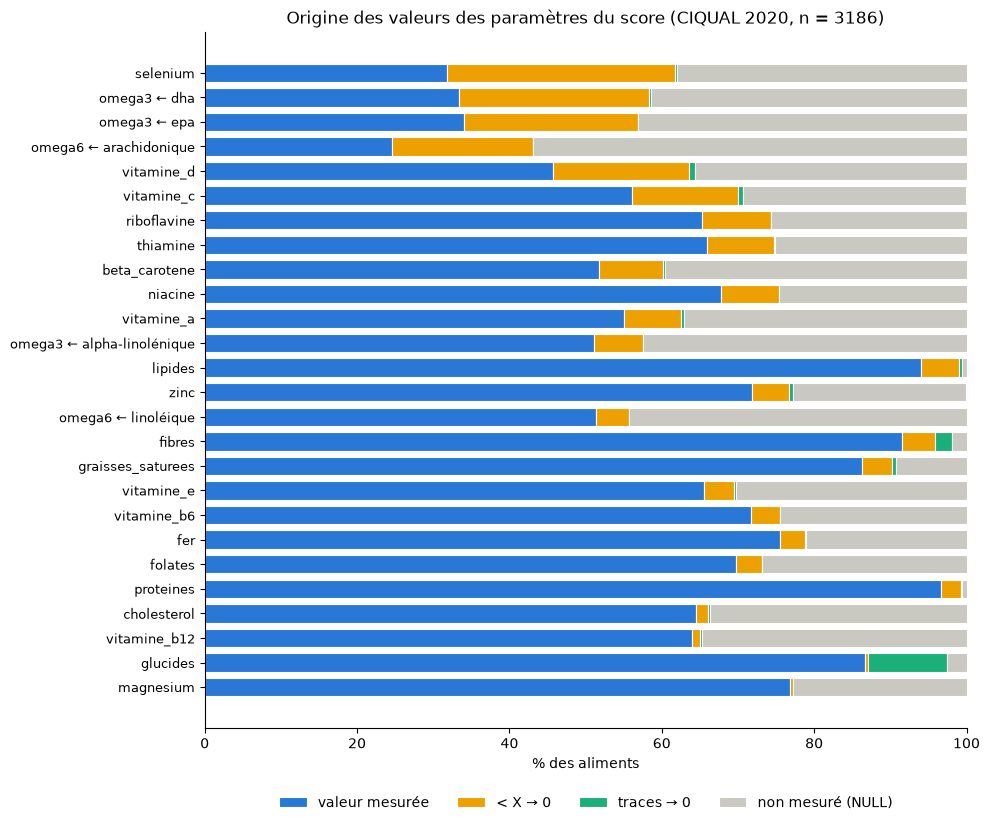

In [17]:
cols_score = dictionnaire.loc[dictionnaire["nom_logique"] != "energie", "colonne_ciqual"].tolist()
ETATS = {"valeur mesurée":    ["nombre (point)", "nombre (virgule)"],
         "< X → 0":           ["inférieur à (< X)"],
         "traces → 0":        ["traces"],
         "non mesuré (NULL)": ["vide", "tiret"]}
COULEURS = {"valeur mesurée": "#2a78d6", "< X → 0": "#eda100",
            "traces → 0": "#1baf7a", "non mesuré (NULL)": "#c9c8c1"}

etat_parametres = pd.DataFrame({etat: formats_cellules[cols_score].isin(fmts).mean() * 100
                                for etat, fmts in ETATS.items()})
etat_parametres.index = dictionnaire.set_index("colonne_ciqual").loc[cols_score, "nom_logique"]
etat_parametres = etat_parametres.sort_values("< X → 0")
print("Tableau 3.3 — État des valeurs par paramètre du score (% des aliments)")
display(etat_parametres.round(1))

fig, ax = plt.subplots(figsize=(10, max(4, 0.32 * len(etat_parametres))))
gauche = np.zeros(len(etat_parametres))
for etat, couleur in COULEURS.items():
    ax.barh(etat_parametres.index, etat_parametres[etat], left=gauche, color=couleur, label=etat,
            height=0.75, edgecolor="white", linewidth=0.8)
    gauche += etat_parametres[etat].values
ax.set_xlim(0, 100)
ax.set_xlabel("% des aliments")
ax.set_title(f"Origine des valeurs des paramètres du score (CIQUAL {CIQUAL_VERSION}, n = {len(brut)})")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=4, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout()
plt.show()

### Lecture § 3.2–3.3
- 27 colonnes CIQUAL identifiées sans ambiguïté (garde-fou : 1 mot-clé = 1 colonne), **toutes dans l'unité attendue** par le référentiel v1.0
  → aucune conversion d'unité nécessaire pour CIQUAL ; le contrôle bloque le script si la source change. La conversion g → mg/µg relève de l'ETL Open Food Facts.
- Poids de la convention « < X → 0 » (lower bound EFSA, référentiel v1.0) : marginal sur les macronutriments, magnésium et B12 (≤ 1 %),
  **fort sur le sélénium (29,9 %), DHA (24,9 %), EPA (22,8 %), acide arachidonique (18,5 %), vitamine D (18,0 %)**.
- Conséquence visible dans les repères v1.0 (sélénium : médiane 0,1, p10 0 ; vitamine D : médiane 0) : une valeur « < X » passe sous la médiane
  et reçoit une contribution pro-inflammatoire maximale sur ces paramètres. Limite documentée ; règle non modifiée (figée v1.0).
  Piste V2 : analyse de sensibilité avec la convention X/2.

### 3.4 Construction de la table « aliments », alignée sur backend/app/db/models/aliment.py


In [18]:
# Ordre des paramètres = PARAMETRES_NUTRITIONNELS du backend (copie à garder synchronisée)
PARAMETRES_NUTRITIONNELS = (
    "glucides", "proteines", "lipides", "graisses_saturees", "cholesterol", "fer", "vitamine_b12",
    "fibres", "omega3", "omega6", "vitamine_a", "beta_carotene", "vitamine_c", "vitamine_d",
    "vitamine_e", "vitamine_b6", "folates", "thiamine", "riboflavine", "niacine",
    "magnesium", "selenium", "zinc",
)
COL = dict(zip(dictionnaire["nom_logique"], dictionnaire["colonne_ciqual"]))

# a) Fusion du doublon 9621 (0 conflit mesuré au § 1.6) : la ligne i2 est complétée par la ligne i1
valeurs_fusion = valeurs.copy()
valeurs_fusion.loc[i2] = valeurs.loc[i2].combine_first(valeurs.loc[i1])
assert valeurs_fusion.loc[i2].notna().sum() == valeurs.loc[[i1, i2]].notna().any().sum(), "Fusion avec perte"

lignes_rejetees = [{"alim_code": ident_txt.loc[i1, "alim_code"], "alim_nom_fr": ident_txt.loc[i1, "alim_nom_fr"],
                    "motif": f"doublon de alim_code, valeurs fusionnées dans la ligne {i2}"}]

# b) Catégorie = nom du GROUPE (cf. CATEGORIES_EXCLUES du backend), réparé depuis le code (§ 1.4 : correspondance univoque)
nom_par_code = (ident_txt.loc[ident_txt["alim_grp_nom_fr"] != ""]
                .groupby("alim_grp_code")["alim_grp_nom_fr"].first())
categorie = ident_txt["alim_grp_code"].map(nom_par_code)   # code 00 absent -> NaN -> id_categorie NULL
print(f"Noms de groupe réparés depuis le code : {((ident_txt['alim_grp_nom_fr'] == '') & categorie.notna()).sum()}")
print(f"Aliments sans catégorie (NULL)       : {categorie.isna().sum()}")

# c) Nom : espaces multiples réduits à un seul (le texte reste celui de la source)
nom_normalise = ident_txt["alim_nom_fr"].str.replace(r"\s+", " ", regex=True)
print(f"Noms modifiés par la normalisation des espaces : {(nom_normalise != ident_txt['alim_nom_fr']).sum()}")

# d) Assemblage
aliments = pd.DataFrame({
    "code_ciqual": ident_txt["alim_code"].astype(int),   # clé source : idempotence de l'import (lot C4)
    "nom":         nom_normalise,
    "categorie":   categorie,
    "source":      "CIQUAL",
    "energie":     valeurs_fusion[COL["energie"]],
})
for p in PARAMETRES_NUTRITIONNELS:
    if p in COL:
        aliments[p] = valeurs_fusion[COL[p]]
for omega in COMPOSANTES_OMEGA:   # somme des acides gras ; NULL si aucun constituant mesuré (référentiel §3.3)
    cols_composantes = dictionnaire.loc[dictionnaire["nom_logique"].str.startswith(f"{omega} ←"),
                                        "colonne_ciqual"].tolist()
    aliments[omega] = valeurs_fusion[cols_composantes].sum(axis=1, min_count=1)

aliments = (aliments[["code_ciqual", "nom", "categorie", "source", "energie", *PARAMETRES_NUTRITIONNELS]]
            .drop(index=i1))

# Garde-fous
assert len(aliments) == len(brut) - 1
assert aliments["code_ciqual"].is_unique
assert aliments["nom"].ne("").all()
print(f"Table aliments : {aliments.shape[0]} lignes × {aliments.shape[1]} colonnes")
print("Tableau 3.4 — Contrôle de la ligne fusionnée (9621) et de l'aliment sans catégorie (24999)")
display(aliments[aliments["code_ciqual"].isin([9621, 24999])])

Noms de groupe réparés depuis le code : 44
Aliments sans catégorie (NULL)       : 1
Noms modifiés par la normalisation des espaces : 5
Table aliments : 3185 lignes × 28 colonnes
Tableau 3.4 — Contrôle de la ligne fusionnée (9621) et de l'aliment sans catégorie (24999)


,code_ciqual,nom,categorie,source,energie,glucides,proteines,lipides,graisses_saturees,cholesterol,fer,vitamine_b12,fibres,omega3,omega6,vitamine_a,beta_carotene,vitamine_c,vitamine_d,vitamine_e,vitamine_b6,folates,thiamine,riboflavine,niacine,magnesium,selenium,zinc
0,24999,Dessert (aliment moyen),NaN,CIQUAL,NaN,36.6,4.61,12.90,5.18,56.7,1.45,0.21,1.54,0.3792,1.3320,56.3,34.6,1.37,0.27,1.97,0.056,30.8,0.084,0.15,0.61,23.8,7.04,0.50
3121,9621,Son de blé,aides culinaires et ingrédients divers,CIQUAL,279.0,23.6,15.20,4.35,0.84,0.0,14.80,0.00,42.00,0.1600,2.3281,0.0,6.0,0.00,0.00,1.55,1.340,110.0,0.710,0.47,21.60,546.0,6.80,7.49


### 3.5 Texte : encodage et longueurs par rapport au schéma PostgreSQL


In [19]:
texte = pd.DataFrame({"nom": aliments["nom"], "categorie": aliments["categorie"].fillna("")})

MOTIF_MOJIBAKE = r"Ã|â€|�"   # traces typiques d'un UTF-8 relu en Latin-1, ou caractère de remplacement
controle_texte = pd.DataFrame({
    "caracteres_suspects (encodage)": texte.apply(lambda s: s.str.contains(MOTIF_MOJIBAKE, regex=True).sum()),
    "longueur_max":                   texte.apply(lambda s: s.str.len().max()),
    "limite_schema":                  pd.Series({"nom": 255, "categorie": 100}),
})
controle_texte["depasse"] = controle_texte["longueur_max"] > controle_texte["limite_schema"]
print("Tableau 3.5 — Contrôle des colonnes texte (schéma : nom VARCHAR(255), categorie.nom VARCHAR(100))")
display(controle_texte)
print("Catégories finales :", sorted(aliments["categorie"].dropna().unique()))

Tableau 3.5 — Contrôle des colonnes texte (schéma : nom VARCHAR(255), categorie.nom VARCHAR(100))


,caracteres_suspects (encodage),longueur_max,limite_schema,depasse
nom,0,149,255,False
categorie,0,43,100,False


Catégories finales : ['aides culinaires et ingrédients divers', 'aliments infantiles', 'eaux et autres boissons', 'entrées et plats composés', 'fruits, légumes, légumineuses et oléagineux', 'glaces et sorbets', 'matières grasses', 'produits céréaliers', 'produits laitiers et assimilés', 'produits sucrés', 'viandes, œufs, poissons et assimilés']


### Lecture § 3.4–3.5
- Table `aliments` : **3 185 lignes** (3 186 − 1 doublon fusionné) × 28 colonnes, alignée sur `backend/app/db/models/aliment.py`
  (+ `code_ciqual`, clé source pour l'import idempotent).
- Catégorie = groupe CIQUAL (11 valeurs, identiques aux noms utilisés par `CATEGORIES_EXCLUES` du backend) ;
  44 noms réparés depuis le code `03` ; 1 aliment sans catégorie (24999, code 00) → `id_categorie` NULL.
- Texte : 0 caractère d'encodage suspect ; longueurs max 149 (nom, limite 255) et 43 (catégorie, limite 100).

### 3.6 Les 5 noms modifiés par la normalisation des espaces (vérification avant/après)


In [20]:
noms_modifies = pd.DataFrame({"avant": ident_txt["alim_nom_fr"], "apres": nom_normalise})
noms_modifies = noms_modifies[noms_modifies["avant"] != noms_modifies["apres"]]
noms_modifies["avant_visible"] = noms_modifies["avant"].str.replace(" ", "·")   # rend les espaces visibles
print(f"Tableau 3.6 — Noms modifiés ({len(noms_modifies)})")
display(noms_modifies[["avant_visible", "apres"]])

Tableau 3.6 — Noms modifiés (5)


,avant_visible,apres
86,"Paupiette·de·veau,·préemballée,··cuite·au·four","Paupiette de veau, préemballée, cuite au four"
121,"Gratin·ou·cassolette·de·poisson·et·/·ou·fruits·de·mer,··préemballé,·cru","Gratin ou cassolette de poisson et / ou fruits de mer, préemballé, cru"
891,"Pomme·cannelle,··pulpe,·crue,·prélevée·à·la·Martinique","Pomme cannelle, pulpe, crue, prélevée à la Martinique"
1027,"Pain,·baguette·ou·boule,·bis·(à·la·farine·T80 ou·T110)","Pain, baguette ou boule, bis (à la farine T80 ou T110)"
1927,Bouchées·ou·émincé·au·soja·et·blé··(ne·convient·pas·aux·véganes·ou·végétalie...,Bouchées ou émincé au soja et blé (ne convient pas aux véganes ou végétalien...


## 4. Entrées corrompues : règles de cohérence physique

Le § 2 a montré qu'aucun aliment n'est vide. Une entrée « corrompue » est donc ici une entrée **physiquement impossible** :
une valeur qui ne peut pas exister dans un aliment réel, quel qu'il soit. On **mesure d'abord** chaque règle, on regarde les lignes,
puis on décide des seuils et des suppressions.

-------------------------
### 4.1 Mesure des règles de cohérence (AUCUNE suppression à ce stade)


In [21]:
valeurs_alim = valeurs_fusion.drop(index=i1)          # mêmes lignes que la table aliments
assert valeurs_alim.index.equals(aliments.index)

def col(*mots: str) -> pd.Series:
    """Colonne convertie (float) de valeurs_alim, retrouvée par mots-clés uniques."""
    return valeurs_alim[trouve_colonne_unique(cols_nutri, list(mots))]

# Toutes les teneurs ramenées en grammes pour 100 g (pour la règle « > 100 g »)
FACTEUR_EN_G = {"g": 1.0, "mg": 1e-3, "µg": 1e-6}
cols_masse = [c for c in cols_nutri if unite_colonne(c) in FACTEUR_EN_G]
en_grammes = valeurs_alim[cols_masse].mul([FACTEUR_EN_G[unite_colonne(c)] for c in cols_masse], axis=1)
print(f"Colonnes exprimées en masse : {len(cols_masse)} / {len(cols_nutri)} (les autres = énergie)")

lipides, satures = col("lipides (g"), col("ag saturés")
ag_total = satures + col("ag monoinsaturés") + col("ag polyinsaturés")
glucides, sucres = col("glucides (g"), col("sucres (g")
omegas = aliments["omega3"].fillna(0) + aliments["omega6"].fillna(0)
composition = pd.concat([col("eau (g"), col("protéines, n x facteur de jones"), glucides, lipides,
                         col("fibres alimentaires"), col("alcool"), col("cendres"),
                         col("acides organiques"), col("polyols")], axis=1).sum(axis=1, min_count=1)

# Chaque règle : (masque des aliments en infraction, écart à la limite en g/100 g)
# Une comparaison avec NaN vaut False : une valeur non mesurée ne déclenche jamais une règle.
regles = {
    "R1 valeur négative":              ((valeurs_alim < 0).any(axis=1), -valeurs_alim.min(axis=1)),
    "R2 teneur > 100 g/100 g":         ((en_grammes > 100).any(axis=1), en_grammes.max(axis=1) - 100),
    "R3 AG saturés > lipides":         (satures > lipides, satures - lipides),
    "R4 AG sat+mono+poly > lipides":   (ag_total > lipides, ag_total - lipides),
    "R5 sucres > glucides":            (sucres > glucides, sucres - glucides),
    "R6 oméga-3 + oméga-6 > lipides":  (omegas > lipides, omegas - lipides),
    "R7 somme de composition > 100 g": (composition > 100, composition - 100),
}
bilan_regles = pd.DataFrame({
    nom: {"n_aliments":   int(masque.sum()),
          "ecart_median": ecart[masque].median() if masque.any() else np.nan,
          "ecart_max":    ecart[masque].max() if masque.any() else np.nan}
    for nom, (masque, ecart) in regles.items()}).T
print("Tableau 4.1a — Infractions aux règles de cohérence physique (écarts en g/100 g)")
display(bilan_regles.round(3))

print("Tableau 4.1b — Distribution de la somme de composition (g/100 g)")
display(composition.describe(percentiles=[.01, .5, .99]).round(2).to_frame("somme_composition").T)

Colonnes exprimées en masse : 63 / 67 (les autres = énergie)
Tableau 4.1a — Infractions aux règles de cohérence physique (écarts en g/100 g)


,n_aliments,ecart_median,ecart_max
R1 valeur négative,0.0,NaN,NaN
R2 teneur > 100 g/100 g,0.0,NaN,NaN
R3 AG saturés > lipides,2.0,0.322,0.600
R4 AG sat+mono+poly > lipides,8.0,0.020,0.360
R5 sucres > glucides,2.0,0.015,0.021
R6 oméga-3 + oméga-6 > lipides,1.0,0.105,0.105
R7 somme de composition > 100 g,1439.0,0.270,96.820


Tableau 4.1b — Distribution de la somme de composition (g/100 g)


,count,mean,std,min,1%,50%,99%,max
somme_composition,3185.0,93.07,21.87,0.0,5.32,99.99,103.06,196.82


### 4.2 Cohérence de l'énergie déclarée avec les macronutriments (Règlement UE 1169/2011, annexe XIV)
kcal = 4×protéines + 4×glucides + 9×lipides + 2×fibres + 7×alcool + 3×acides organiques + 2,4×polyols  
Un grand écart signale une valeur saisie fausse (virgule déplacée, mauvaise colonne…).

Aliments comparables (4 macros mesurées + énergie > 0) : 2201 / 3185
Tableau 4.2 — |écart| entre énergie déclarée et énergie recalculée (%)


,count,mean,std,min,50%,90%,99%,max
|écart| (%),2201.0,0.98,5.54,0.0,0.13,1.68,13.81,164.4


  |écart| >  5 % : 99 aliments
  |écart| > 10 % : 35 aliments
  |écart| > 20 % : 14 aliments
  |écart| > 50 % : 4 aliments


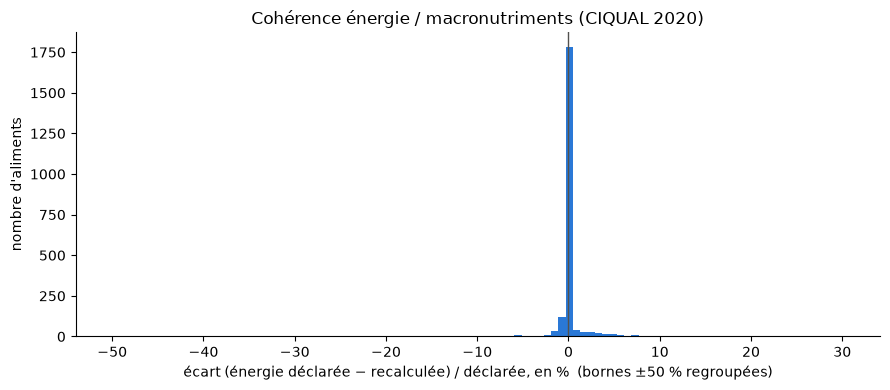

In [22]:
proteines_625, fibres = col("protéines, n x 6.25"), col("fibres alimentaires")
majeurs_mesures = pd.concat([proteines_625, glucides, lipides, fibres], axis=1).notna().all(axis=1)
energie_calculee = (4 * proteines_625 + 4 * glucides + 9 * lipides + 2 * fibres
                    + 7 * col("alcool").fillna(0) + 3 * col("acides organiques").fillna(0)
                    + 2.4 * col("polyols").fillna(0))
energie_declaree = col("règlement ue", "kcal")
comparables = majeurs_mesures & energie_declaree.gt(0)
ecart_energie_pct = ((energie_declaree - energie_calculee) / energie_declaree * 100)[comparables]

print(f"Aliments comparables (4 macros mesurées + énergie > 0) : {comparables.sum()} / {len(valeurs_alim)}")
print("Tableau 4.2 — |écart| entre énergie déclarée et énergie recalculée (%)")
display(ecart_energie_pct.abs().describe(percentiles=[.5, .9, .99]).round(2).to_frame("|écart| (%)").T)
for seuil in (5, 10, 20, 50):
    print(f"  |écart| > {seuil:>2} % : {(ecart_energie_pct.abs() > seuil).sum()} aliments")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(ecart_energie_pct.clip(-50, 50), bins=100, color="#2a78d6")
ax.axvline(0, color="#52514e", lw=1)
ax.set_xlabel("écart (énergie déclarée − recalculée) / déclarée, en %  (bornes ±50 % regroupées)")
ax.set_ylabel("nombre d'aliments")
ax.set_title("Cohérence énergie / macronutriments (CIQUAL 2020)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### Lecture § 3.6 et 4.1–4.2
- 3.6 : 5 noms modifiés, uniquement des espaces doubles ou spéciaux → validé.
- R1 (valeur négative) et R2 (> 100 g/100 g) : **0 aliment**.
- R3–R6 (sous-ensemble > ensemble : AG saturés > lipides, sucres > glucides…) : 13 infractions, écarts 0,015 à 0,6 g → arrondis probables, à vérifier ligne à ligne.
- R7 (somme de composition > 100 g) : 1 439 aliments, mais excédent médian 0,27 g et 99ᵉ centile 103,06 g → **un seuil strict à 100 g est inadapté**
  (constituants analysés séparément) ; maximum 196,82 g = cas anormal à examiner.
- Énergie déclarée vs recalculée (UE 1169/2011) sur 2 201 aliments comparables : écart médian 0,13 %, P90 1,68 %, P99 13,81 % ;
  **4 aliments > 50 %** (max 164 %) = candidats « entrée corrompue ».

### 4.3 Règles R3 à R6 : les lignes en infraction


In [23]:
regles_declenchees = pd.DataFrame({nom.split()[0]: masque for nom, (masque, _) in regles.items()})
etiquette_regles = regles_declenchees.apply(lambda ligne: ", ".join(ligne.index[ligne]), axis=1)

masque_r3_r6 = regles_declenchees[["R3", "R4", "R5", "R6"]].any(axis=1)
vue_lipides_glucides = pd.DataFrame({
    "code_ciqual": aliments["code_ciqual"], "nom": aliments["nom"].str[:55],
    "regles": etiquette_regles,
    "lipides": lipides, "AG_satures": satures, "AG_sat+mono+poly": ag_total,
    "omega3+6": omegas, "glucides": glucides, "sucres": sucres,
})[masque_r3_r6]
print(f"Tableau 4.3 — Aliments en infraction R3 à R6 ({len(vue_lipides_glucides)})")
display(vue_lipides_glucides.round(3))

Tableau 4.3 — Aliments en infraction R3 à R6 (12)


,code_ciqual,nom,regles,lipides,AG_satures,AG_sat+mono+poly,omega3+6,glucides,sucres
678,4048,"Pomme de terre, cuite (aliment moyen)","R4, R7",1.370,0.400,1.730,0.194,17.20,1.050
1313,28001,"Porc, épaule, crue","R4, R7",11.200,4.410,11.210,1.127,0.38,0.000
1561,8551,"Andouillette, sautée/poêlée",R4,22.300,11.100,22.320,2.720,1.00,0.000
1759,26173,"Sprat, cru",R4,11.900,3.320,11.920,3.020,0.00,0.000
2104,12034,Fromage à pâte molle et croûte lavée (aliment moyen),"R5, R7",26.500,17.600,24.840,0.538,0.00,0.021
2152,12100,Fromage à pâte pressée cuite (aliment moyen),R5,30.800,20.100,28.540,0.609,0.00,0.009
2170,12723,"Cantal, Salers ou Laguiole","R4, R7",31.000,24.200,31.040,0.643,0.00,0.000
2223,19411,"Crème d'Isigny AOP, >= 35% MG","R4, R7",40.000,28.900,40.020,0.000,3.00,2.050
2444,18004,"Café, non instantané, non sucré, prêt à boire",R4,0.018,0.002,0.018,0.000,1.35,0.000
2601,31110,"Confiture, tout type de fruits, allégée en sucres (extr","R3, R6",0.000,0.044,NaN,0.105,38.00,38.000


### 4.4 R7 et énergie : les cas extrêmes, avec tous leurs constituants

In [24]:
# Une seule vue pour les deux contrôles : on voit si les extrêmes de R7 sont aussi des extrêmes d'énergie.
vue_composition = pd.DataFrame({
    "code_ciqual": aliments["code_ciqual"], "nom": aliments["nom"].str[:45],
    "eau": col("eau (g"), "prot_jones": col("protéines, n x facteur de jones"), "glucides": glucides,
    "lipides": lipides, "fibres": fibres, "alcool": col("alcool"), "cendres": col("cendres"),
    "ac_org": col("acides organiques"), "polyols": col("polyols"),
    "somme": composition,
    "kcal_declare": energie_declaree, "kcal_recalcule": energie_calculee,
    "ecart_kcal_%": ecart_energie_pct.reindex(aliments.index),
})
print("Tableau 4.4a — Les 15 sommes de composition les plus élevées")
display(vue_composition.nlargest(15, "somme").round(2))
print("Tableau 4.4b — Les 15 plus grands écarts d'énergie (en valeur absolue)")
display(vue_composition.loc[vue_composition["ecart_kcal_%"].abs().nlargest(15).index].round(2))

Tableau 4.4a — Les 15 sommes de composition les plus élevées


,code_ciqual,nom,eau,prot_jones,glucides,lipides,fibres,alcool,cendres,ac_org,polyols,somme,kcal_declare,kcal_recalcule,ecart_kcal_%
2538,31087,Édulcorant à base d'extrait de stévia,NaN,0.00,98.0,0.20,0.50,0.0,0.42,0.00,97.70,196.82,238.0,629.28,-164.40
2580,31054,"Chewing-gum, sans sucre",4.30,0.69,78.1,0.45,1.98,0.0,11.80,0.00,59.70,157.02,228.0,466.45,-104.58
2549,31020,"Chocolat au lait sans sucres ajoutés, avec éd",NaN,5.75,54.2,34.60,2.00,0.0,0.62,0.00,42.60,139.77,487.0,657.44,-35.00
2587,31121,"Chewing-gum, teneur en sucre inconnue (alimen",3.84,0.53,82.5,0.41,2.12,0.0,8.71,0.10,38.70,136.91,279.0,433.23,-55.28
2525,11506,"Édulcorant à l'aspartame, en pastilles",NaN,6.35,69.3,0.00,2.20,0.0,0.82,0.00,57.00,135.67,216.0,443.80,-105.46
2551,31030,"Chocolat noir sans sucres ajoutés, avec édulc",0.60,8.48,34.1,42.30,10.20,0.0,1.25,0.00,28.90,125.83,525.0,640.78,-22.05
845,13001,"Abricot, dénoyauté, sec",24.70,2.88,59.1,0.50,8.30,0.0,2.51,1.98,22.60,122.57,239.0,329.20,-37.74
855,13623,"Abricot, dénoyauté, sec, moelleux (réhydraté",39.30,2.31,51.1,0.40,3.50,0.0,1.96,1.43,17.60,117.60,200.0,270.77,-35.38
2680,24616,"Biscuit sec type tuile, aux fruits",NaN,5.43,74.9,8.28,7.14,0.0,0.70,0.00,16.40,112.85,384.0,449.48,-17.05
848,13042,"Pruneau, sec",34.90,1.63,55.4,0.40,5.10,0.0,1.72,0.90,9.60,109.65,229.0,267.66,-16.88


Tableau 4.4b — Les 15 plus grands écarts d'énergie (en valeur absolue)


,code_ciqual,nom,eau,prot_jones,glucides,lipides,fibres,alcool,cendres,ac_org,polyols,somme,kcal_declare,kcal_recalcule,ecart_kcal_%
2538,31087,Édulcorant à base d'extrait de stévia,NaN,0.00,98.00,0.20,0.50,0.0,0.42,0.00,97.7,196.82,238.00,629.28,-164.40
2525,11506,"Édulcorant à l'aspartame, en pastilles",NaN,6.35,69.30,0.00,2.20,0.0,0.82,0.00,57.0,135.67,216.00,443.80,-105.46
2580,31054,"Chewing-gum, sans sucre",4.30,0.69,78.10,0.45,1.98,0.0,11.80,0.00,59.7,157.02,228.00,466.45,-104.58
2587,31121,"Chewing-gum, teneur en sucre inconnue (alimen",3.84,0.53,82.50,0.41,2.12,0.0,8.71,0.10,38.7,136.91,279.00,433.23,-55.28
845,13001,"Abricot, dénoyauté, sec",24.70,2.88,59.10,0.50,8.30,0.0,2.51,1.98,22.6,122.57,239.00,329.20,-37.74
855,13623,"Abricot, dénoyauté, sec, moelleux (réhydraté",39.30,2.31,51.10,0.40,3.50,0.0,1.96,1.43,17.6,117.60,200.00,270.77,-35.38
2549,31020,"Chocolat au lait sans sucres ajoutés, avec éd",NaN,5.75,54.20,34.60,2.00,0.0,0.62,0.00,42.6,139.77,487.00,657.44,-35.00
514,20125,"Champignon de Paris ou champignon de couche,",88.40,4.44,4.53,0.60,0.90,0.0,1.10,0.03,3.0,103.00,38.40,50.36,-31.16
980,25579,"Gnocchi, cuit (aliment moyen)",54.80,6.34,34.00,7.88,1.90,0.0,1.53,0.00,0.0,106.45,181.00,236.08,-30.43
2394,18025,"Kombucha, préemballé",97.60,0.00,1.45,0.00,0.00,0.0,0.04,0.27,0.0,99.36,9.46,6.61,30.13


### Lecture § 4.3–4.4
- Les extrêmes de R7 et de l'écart d'énergie sont des produits riches en **polyols** (édulcorants, chewing-gums, chocolats sans sucres, fruits secs).
- *Hypothèse* : dans CIQUAL, « glucides » inclut les polyols (définition du Règlement UE 1169/2011) → **mes formules de contrôle comptaient
  les polyols deux fois**. Vérification manuelle : stévia 238 kcal déclarées / ≈ 238,5 recalculées après correction ; chewing-gum 228 / ≈ 227,7 ;
  abricot sec 239 / ≈ 239 ; pruneau 229 / ≈ 229. → à mesurer sur tout le jeu (4.5).
- R3–R6 : écarts d'arrondi (R4) ou probable effet de la convention « < X → 0 » sur lipides/glucides (R3, R5, R6) → à vérifier sur les valeurs brutes (4.6).

### 4.5 Hypothèse « glucides inclut les polyols » : correction des deux contrôles et nouvelle mesure


In [25]:
polyols = col("polyols").fillna(0)
print(f"Aliments avec polyols > 0                              : {(polyols > 0).sum()}")
print(f"Aliments où polyols > glucides (contredit l'hypothèse) : {(polyols > glucides).sum()}")

composition_corr = composition - polyols              # retire le double compte
energie_calculee_corr = energie_calculee - 4 * polyols  # les polyols ne gardent que leur coefficient 2,4
ecart_corr_pct  = ((energie_declaree - energie_calculee_corr) / energie_declaree * 100)[comparables]
ecart_corr_kcal = (energie_declaree - energie_calculee_corr)[comparables]

avant_apres = pd.DataFrame({
    "avant (polyols comptés 2 fois)": {
        **{f"somme composition > {s} g": int((composition > s).sum()) for s in (100, 102, 105, 110)},
        **{f"|écart énergie| > {s} %": int((ecart_energie_pct.abs() > s).sum()) for s in (5, 10, 20, 50)}},
    "après correction": {
        **{f"somme composition > {s} g": int((composition_corr > s).sum()) for s in (100, 102, 105, 110)},
        **{f"|écart énergie| > {s} %": int((ecart_corr_pct.abs() > s).sum()) for s in (5, 10, 20, 50)}},
})
print("Tableau 4.5a — Effet de la correction sur les deux contrôles")
display(avant_apres)

vue_composition["somme_corr"] = composition_corr
vue_composition["ecart_kcal_corr_%"] = ecart_corr_pct.reindex(aliments.index)
vue_composition["ecart_kcal_corr"] = ecart_corr_kcal.reindex(aliments.index)
cols_vue = ["code_ciqual", "nom", "eau", "glucides", "polyols", "lipides", "alcool",
            "somme_corr", "kcal_declare", "ecart_kcal_corr", "ecart_kcal_corr_%"]
print("Tableau 4.5b — Après correction : les 10 sommes les plus élevées")
display(vue_composition.nlargest(10, "somme_corr")[cols_vue].round(2))
print("Tableau 4.5c — Après correction : les 15 plus grands écarts d'énergie (%)")
display(vue_composition.loc[vue_composition["ecart_kcal_corr_%"].abs().nlargest(15).index, cols_vue].round(2))

Aliments avec polyols > 0                              : 174
Aliments où polyols > glucides (contredit l'hypothèse) : 0
Tableau 4.5a — Effet de la correction sur les deux contrôles


,avant (polyols comptés 2 fois),après correction
somme composition > 100 g,1439,1387
somme composition > 102 g,196,166
somme composition > 105 g,17,1
somme composition > 110 g,9,0
|écart énergie| > 5 %,99,68
|écart énergie| > 10 %,35,22
|écart énergie| > 20 %,14,2
|écart énergie| > 50 %,4,0


Tableau 4.5b — Après correction : les 10 sommes les plus élevées


,code_ciqual,nom,eau,glucides,polyols,lipides,alcool,somme_corr,kcal_declare,ecart_kcal_corr,ecart_kcal_corr_%
980,25579,"Gnocchi, cuit (aliment moyen)",54.80,34.0,0.0,7.88,0.0,106.45,181.0,-55.08,-30.43
3031,11174,"Bouillon de volaille, déshydraté",9.37,20.8,0.0,11.50,0.0,103.15,233.0,-0.06,-0.03
170,25081,Lasagnes ou cannelloni à la viande (bolognais,74.30,13.5,0.0,5.72,0.0,103.09,134.0,-0.46,-0.34
665,4032,"Frites de pommes de terre, surgelées, cuites",42.50,39.4,0.0,11.90,0.0,103.09,285.0,-0.62,-0.22
675,4045,"Frites de pommes de terre, surgelées, préfrit",49.50,34.0,0.0,10.80,0.0,103.08,254.0,-0.86,-0.34
692,20293,"Haricot coco, bouilli/cuit à l'eau",61.30,13.7,0.0,0.50,0.0,103.08,131.0,-0.40,-0.31
1563,8703,"Boudin noir, à cuire",56.00,4.5,0.0,27.10,0.0,103.07,313.0,-0.54,-0.17
725,20530,"Haricot mungo, sec",9.52,47.6,NaN,1.42,0.0,103.07,NaN,NaN,NaN
2984,11158,"Sauce au beurre, préemballée",75.30,5.2,NaN,17.90,0.0,103.07,NaN,NaN,NaN
1574,28504,"Lardon nature, cuit",48.20,2.0,0.0,24.50,0.0,103.06,324.0,0.30,0.09


Tableau 4.5c — Après correction : les 15 plus grands écarts d'énergie (%)


,code_ciqual,nom,eau,glucides,polyols,lipides,alcool,somme_corr,kcal_declare,ecart_kcal_corr,ecart_kcal_corr_%
980,25579,"Gnocchi, cuit (aliment moyen)",54.8,34.00,0.00,7.88,0.0,106.45,181.00,-55.08,-30.43
2394,18025,"Kombucha, préemballé",97.6,1.45,0.00,0.00,0.0,99.36,9.46,2.85,30.13
2383,18011,Eau de coco,95.7,3.33,0.70,0.00,0.0,99.53,15.20,2.85,18.73
9,25616,"Crudité, sans assaisonnement (aliment moyen)",93.2,3.07,0.29,0.70,0.0,100.20,29.90,4.72,15.79
2444,18004,"Café, non instantané, non sucré, prêt à boire",97.8,1.35,0.00,0.02,0.0,99.56,6.88,1.08,15.76
67,25972,"Soupe miso, déshydratée reconstituée",94.6,2.18,0.00,0.00,0.0,99.51,17.10,2.69,15.71
2463,18059,"Boisson concentrée à diluer, sans sucres ajou",93.8,2.76,0.00,0.00,0.0,99.46,21.70,3.26,15.02
2448,18071,"Café expresso, non instantané, non sucré, prê",97.8,1.16,0.00,0.20,0.0,99.49,7.64,1.10,14.41
574,20317,"Fenouil, cuit à l'étouffée",95.1,1.94,0.00,0.00,0.0,99.60,13.70,1.95,14.23
3010,11004,"Cornichon, au vinaigre",93.7,0.78,0.00,0.00,0.0,101.45,19.40,2.68,13.81


### 4.6 R3 à R6 : valeurs BRUTES — convention « < X → 0 » ou vraie incohérence ?


In [26]:
cols_brutes = {"lipides": COL["lipides"], "AG_satures": COL["graisses_saturees"],
               "glucides": COL["glucides"], "sucres": trouve_colonne_unique(cols_nutri, ["sucres (g"])}
valeurs_brutes_r3_r6 = brut.loc[vue_lipides_glucides.index, list(cols_brutes.values())]
valeurs_brutes_r3_r6.columns = [f"{k} (brut)" for k in cols_brutes]
print("Tableau 4.6 — Valeurs BRUTES (avant conversion) des aliments en infraction R3 à R6")
display(pd.concat([vue_lipides_glucides[["code_ciqual", "nom", "regles"]], valeurs_brutes_r3_r6], axis=1))

Tableau 4.6 — Valeurs BRUTES (avant conversion) des aliments en infraction R3 à R6


,code_ciqual,nom,regles,lipides (brut),AG_satures (brut),glucides (brut),sucres (brut)
678,4048,"Pomme de terre, cuite (aliment moyen)","R4, R7","1,37","0,4","17,2","1,05"
1313,28001,"Porc, épaule, crue","R4, R7","11,2","4,41","0,38",0
1561,8551,"Andouillette, sautée/poêlée",R4,"22,3","11,1",1,"< 0,2"
1759,26173,"Sprat, cru",R4,"11,9","3,32",traces,0
2104,12034,Fromage à pâte molle et croûte lavée (aliment moyen),"R5, R7","26,5","17,6",0,"0,021"
2152,12100,Fromage à pâte pressée cuite (aliment moyen),R5,"30,8","20,1",0,"0,0086"
2170,12723,"Cantal, Salers ou Laguiole","R4, R7",31,"24,2",traces,"< 0,5"
2223,19411,"Crème d'Isigny AOP, >= 35% MG","R4, R7",40,"28,9",3,"2,05"
2444,18004,"Café, non instantané, non sucré, prêt à boire",R4,"0,018","0,002","1,35",traces
2601,31110,"Confiture, tout type de fruits, allégée en sucres (extr","R3, R6","< 0,3","0,044",38,38


### Lecture § 4.5–4.6 et décisions
- Hypothèse « glucides CIQUAL incluent les polyols » **confirmée** : 174 aliments avec polyols, 0 avec polyols > glucides.
  Après correction du double compte : composition > 105 g : 17 → 1 ; |écart énergie| > 50 % : 4 → 0, > 20 % : 14 → 2.
- R3–R6 (valeurs brutes) : arrondis (R4, R5 — glucides « 0 » dans la source, sucres ≤ 0,021 g), artefact de convention
  (confiture : lipides « < 0,3 »), une incohérence mineure de la source (estragon : lipides « traces », AG saturés 0,6 g). Aucun écart > 1 g → conservés.
- **Règles d'entrée corrompue retenues** (constantes du script) :
  | Règle | Seuil | Justification |
  |---|---|---|
  | Valeur négative | < 0 | impossible physiquement (0 cas) |
  | Teneur > 100 g/100 g | toutes unités ramenées en g | impossible physiquement (0 cas) |
  | Sous-ensemble > ensemble | + 1 g | au-delà des arrondis observés (max 0,6 g) |
  | Somme de composition (polyols corrigés) | > 105 g | plafond observé ≈ 103,1 g (constituants analysés séparément) |
  | Énergie déclarée vs recalculée (UE 1169/2011) | > 20 % **et** > 20 kcal | le % seul pénalise les aliments peu énergétiques (kombucha : 30 % = 2,85 kcal) |
- Seule entrée concernée : **Gnocchi, cuit (aliment moyen)**, 25579 (106,45 g ; −55 kcal, −30 %), deux contrôles indépendants → supprimée.

##